In [2]:
"""
HR Estimation from BVP/PPG Signals using Sliding Windows
=========================================================
Pipeline:
  1. Load all .npy chunks per subject
  2. Concatenate chunks per subject → full signal
  3. Apply sliding window (overlapping & non-overlapping)
  4. Detect peaks per window → compute HR
  5. Mean HR per subject
"""

import os
import glob
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from collections import defaultdict


# =============================================================================
# CONFIG
# =============================================================================
FPS = 30                         # Sampling rate (frames per second)
WINDOW_SIZES_SEC = [3, 4, 5]    # Window sizes to test in seconds
OVERLAP_RATIO = 0.5              # 50% overlap for overlapping windows
GT_DIR = "GT_ref/"               # Directory with .npy files

# Peak detection parameters (tuned for BVP signal)
PEAK_PROMINENCE = 0.3
PEAK_DISTANCE_SEC = 0.3          # Min distance between peaks in seconds


# =============================================================================
# STEP 1: LOAD & GROUP BY SUBJECT
# =============================================================================
def load_gt_npy_files(gt_dir):
    """
    Load all .npy files and group by subject ID.
    
    Assumes filename format: {subject_id}_label{n}.npy
    e.g. 101_label0.npy, 101_label1.npy, ...
    
    Returns:
        dict: {subject_id: [array_chunk0, array_chunk1, ...]}
    """
    gt_files = sorted(glob.glob(os.path.join(gt_dir, '*.npy')))
    
    subject_chunks = defaultdict(list)
    
    for gt_file in gt_files:
        filename = os.path.basename(gt_file).split('.')[0]  # e.g. '101_label4'
        subject_id = filename.split('_')[0]                 # e.g. '101'
        chunk = np.load(gt_file)
        subject_chunks[subject_id].append(chunk)
    
    print(f"Loaded {len(gt_files)} files across {len(subject_chunks)} subjects")
    for subj, chunks in subject_chunks.items():
        print(f"  Subject {subj}: {len(chunks)} chunks × {chunks[0].shape[0]} samples "
              f"= {len(chunks) * chunks[0].shape[0]} total samples "
              f"≈ {len(chunks) * chunks[0].shape[0] / FPS:.1f}s")
    
    return dict(subject_chunks)


# =============================================================================
# STEP 2: CONCATENATE CHUNKS PER SUBJECT
# =============================================================================
def concatenate_subject_signal(subject_chunks):
    """
    Concatenate all chunks for each subject into one continuous signal.
    
    Returns:
        dict: {subject_id: np.array of shape (total_samples,)}
    """
    subject_signals = {}
    for subject_id, chunks in subject_chunks.items():
        signal = np.concatenate(chunks)
        subject_signals[subject_id] = signal
    return subject_signals


# =============================================================================
# STEP 3A: NON-OVERLAPPING SLIDING WINDOW
# =============================================================================
def sliding_window_non_overlapping(signal, window_size_sec, fps=FPS):
    """
    Split signal into non-overlapping windows of fixed size.
    Step = window_size (no overlap).
    
    Args:
        signal: 1D numpy array (full subject signal)
        window_size_sec: window size in seconds
        fps: sampling rate
    
    Returns:
        list of np.arrays, each of length window_size_samples
    """
    window_size = int(window_size_sec * fps)  # samples
    n_samples = len(signal)
    windows = []
    
    start = 0
    while start + window_size <= n_samples:
        window = signal[start : start + window_size]
        windows.append(window)
        start += window_size  # step = full window (no overlap)
    
    print(f"  [Non-overlapping] window={window_size_sec}s ({window_size} samples): "
          f"{len(windows)} complete windows "
          f"(discarded last {n_samples - start} samples)")
    
    return windows


# =============================================================================
# STEP 3B: OVERLAPPING SLIDING WINDOW
# =============================================================================
def sliding_window_overlapping(signal, window_size_sec, overlap_ratio=OVERLAP_RATIO, fps=FPS):
    """
    Split signal into overlapping windows.
    Step = window_size * (1 - overlap_ratio).
    
    Args:
        signal: 1D numpy array (full subject signal)
        window_size_sec: window size in seconds
        overlap_ratio: fraction of overlap (0.5 = 50%)
        fps: sampling rate
    
    Returns:
        list of np.arrays, each of length window_size_samples
    """
    window_size = int(window_size_sec * fps)               # samples
    step_size   = int(window_size * (1 - overlap_ratio))   # e.g. 50% overlap → step = half window
    n_samples   = len(signal)
    windows     = []
    
    start = 0
    while start + window_size <= n_samples:
        window = signal[start : start + window_size]
        windows.append(window)
        start += step_size
    
    print(f"  [Overlapping {int(overlap_ratio*100)}%] window={window_size_sec}s ({window_size} samples), "
          f"step={step_size} samples: {len(windows)} windows")
    
    return windows


# =============================================================================
# STEP 4: PEAK DETECTION → HR PER WINDOW
# =============================================================================
def detect_hr_from_window(window, fps=FPS,
                           prominence=PEAK_PROMINENCE,
                           min_distance_sec=PEAK_DISTANCE_SEC):
    """
    Detect peaks in a BVP window and compute HR in bpm.
    
    Args:
        window: 1D numpy array (single window of BVP signal)
        fps: sampling rate
        prominence: minimum peak prominence
        min_distance_sec: minimum distance between peaks in seconds
    
    Returns:
        float or None: HR in bpm, or None if insufficient peaks
    """
    min_distance_samples = int(fps * min_distance_sec)
    
    peaks, _ = find_peaks(window,
                           prominence=prominence,
                           distance=min_distance_samples)
    
    if len(peaks) < 2:
        return None  # Not enough peaks to compute HR
    
    # Inter-peak intervals → HR
    peak_intervals_sec = np.diff(peaks) / fps  # seconds between peaks
    hr_per_interval    = 60.0 / peak_intervals_sec  # bpm
    
    return hr_per_interval.mean()


# =============================================================================
# STEP 5: FULL HR ESTIMATION PIPELINE
# =============================================================================
def estimate_hr(signal, window_size_sec, mode='non_overlapping',
                overlap_ratio=OVERLAP_RATIO, fps=FPS):
    """
    Full pipeline: signal → windows → HR per window → mean HR.
    
    Args:
        signal: 1D numpy array (full subject signal)
        window_size_sec: window size in seconds
        mode: 'non_overlapping' or 'overlapping'
        overlap_ratio: only used if mode='overlapping'
        fps: sampling rate
    
    Returns:
        dict with:
            hr_per_window: list of HR values (bpm) per window
            mean_hr: mean HR across all valid windows
            std_hr: std of HR across all valid windows
            n_windows_total: total windows created
            n_windows_valid: windows with enough peaks
    """
    # Get windows
    if mode == 'non_overlapping':
        windows = sliding_window_non_overlapping(signal, window_size_sec, fps)
    elif mode == 'overlapping':
        windows = sliding_window_overlapping(signal, window_size_sec, overlap_ratio, fps)
    else:
        raise ValueError(f"mode must be 'non_overlapping' or 'overlapping', got '{mode}'")
    
    # HR per window
    hr_per_window = []
    for w in windows:
        hr = detect_hr_from_window(w, fps)
        if hr is not None:
            hr_per_window.append(hr)
    
    n_valid = len(hr_per_window)
    
    if n_valid == 0:
        print(f"  ⚠️  No valid windows found for window_size={window_size_sec}s")
        return {
            "hr_per_window": [],
            "mean_hr": None,
            "std_hr": None,
            "n_windows_total": len(windows),
            "n_windows_valid": 0
        }
    
    hr_array = np.array(hr_per_window)
    
    return {
        "hr_per_window": hr_per_window,
        "mean_hr": float(np.mean(hr_array)),
        "std_hr":  float(np.std(hr_array)),
        "n_windows_total": len(windows),
        "n_windows_valid": n_valid
    }


# =============================================================================
# STEP 6: RUN ON ALL SUBJECTS × ALL WINDOW SIZES
# =============================================================================
def run_full_analysis(subject_signals, window_sizes_sec=WINDOW_SIZES_SEC):
    """
    Run HR estimation for all subjects, all window sizes, both modes.
    
    Returns:
        dict: results[subject_id][window_size][mode] = estimate_hr output
    """
    results = {}
    
    for subject_id, signal in subject_signals.items():
        print(f"\n{'='*60}")
        print(f"Subject: {subject_id} | Signal length: {len(signal)} samples "
              f"≈ {len(signal)/FPS:.1f}s")
        print(f"{'='*60}")
        
        results[subject_id] = {}
        
        for ws in window_sizes_sec:
            results[subject_id][ws] = {}
            print(f"\n  Window size: {ws}s")
            
            for mode in ['non_overlapping', 'overlapping']:
                res = estimate_hr(signal, ws, mode=mode)
                results[subject_id][ws][mode] = res
                
                if res['mean_hr'] is not None:
                    print(f"    [{mode:>17}] "
                          f"Mean HR = {res['mean_hr']:5.1f} bpm | "
                          f"Std = {res['std_hr']:4.1f} | "
                          f"Valid windows = {res['n_windows_valid']}/{res['n_windows_total']}")
    
    return results


# =============================================================================
# STEP 7: SUMMARY TABLE
# =============================================================================
def print_summary_table(results):
    """Print a clean summary table of all results."""
    print(f"\n{'='*80}")
    print("SUMMARY TABLE")
    print(f"{'='*80}")
    print(f"{'Subject':<10} {'Window':>8} {'Mode':<20} {'Mean HR':>10} {'Std':>8} {'Valid/Total':>12}")
    print(f"{'-'*80}")
    
    for subject_id in sorted(results.keys()):
        for ws in sorted(results[subject_id].keys()):
            for mode in ['non_overlapping', 'overlapping']:
                res = results[subject_id][ws][mode]
                mean = f"{res['mean_hr']:.1f}" if res['mean_hr'] else "N/A"
                std  = f"{res['std_hr']:.1f}"  if res['std_hr']  else "N/A"
                valid = f"{res['n_windows_valid']}/{res['n_windows_total']}"
                print(f"{subject_id:<10} {str(ws)+'s':>8} {mode:<20} {mean:>10} {std:>8} {valid:>12}")
        print(f"{'-'*80}")


# =============================================================================
# STEP 8: VISUALIZATION
# =============================================================================
def plot_subject_signal_with_windows(signal, subject_id, window_size_sec=3, fps=FPS):
    """
    Plot the full subject signal with window boundaries overlaid.
    """
    window_size = int(window_size_sec * fps)
    time_axis   = np.arange(len(signal)) / fps
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f"Subject {subject_id} — BVP Signal with {window_size_sec}s Windows", fontsize=13)
    
    for ax, mode, color in zip(axes,
                                ['non_overlapping', 'overlapping'],
                                ['steelblue', 'darkorange']):
        ax.plot(time_axis, signal, color='gray', linewidth=0.8, alpha=0.7, label='BVP signal')
        
        # Get windows
        if mode == 'non_overlapping':
            windows_list = sliding_window_non_overlapping(signal, window_size_sec, fps)
            step = window_size
        else:
            step = int(window_size * (1 - OVERLAP_RATIO))
            windows_list = sliding_window_overlapping(signal, window_size_sec, fps=fps)
        
        # Draw window boundaries
        for i in range(len(windows_list)):
            start_t = (i * step) / fps
            end_t   = start_t + window_size_sec
            ax.axvspan(start_t, end_t, alpha=0.08, color=color)
            ax.axvline(start_t, color=color, linewidth=0.5, alpha=0.5)
        
        # Detect and plot peaks for first window as example
        w0 = windows_list[0]
        peaks, _ = find_peaks(w0, prominence=PEAK_PROMINENCE,
                              distance=int(fps * PEAK_DISTANCE_SEC))
        peak_times = peaks / fps
        ax.plot(peak_times, w0[peaks], 'rv', markersize=8, label='Peaks (window 1)')
        
        ax.set_ylabel("BVP Amplitude")
        ax.set_title(f"Mode: {mode.replace('_', ' ').title()}")
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel("Time (seconds)")
    plt.tight_layout()
    plt.savefig(f"subject_{subject_id}_windows_{window_size_sec}s.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved: subject_{subject_id}_windows_{window_size_sec}s.png")


# =============================================================================
# MAIN
# =============================================================================
# if __name__ == "__main__":
    
#     # 1. Load files grouped by subject
#     subject_chunks = load_gt_npy_files(GT_DIR)
    
#     # 2. Concatenate chunks per subject
#     subject_signals = concatenate_subject_signal(subject_chunks)
    
#     # 3. Run full analysis
#     results = run_full_analysis(subject_signals, window_sizes_sec=WINDOW_SIZES_SEC)
    
#     # 4. Print summary
#     print_summary_table(results)
    
#     # 5. Plot one subject as example
#     first_subject = sorted(subject_signals.keys())[0]
#     plot_subject_signal_with_windows(subject_signals[first_subject],
#                                       subject_id=first_subject,
#                                       window_size_sec=3)

Loaded 12 files across 1 subjects
  Subject 101: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s

Subject: 101 | Signal length: 1920 samples ≈ 64.0s

  Window size: 3s
  [Non-overlapping] window=3s (90 samples): 21 complete windows (discarded last 30 samples)
    [  non_overlapping] Mean HR =  67.9 bpm | Std =  4.2 | Valid windows = 21/21
  [Overlapping 50%] window=3s (90 samples), step=45 samples: 41 windows
    [      overlapping] Mean HR =  68.0 bpm | Std =  4.2 | Valid windows = 41/41

  Window size: 4s
  [Non-overlapping] window=4s (120 samples): 16 complete windows (discarded last 0 samples)
    [  non_overlapping] Mean HR =  68.0 bpm | Std =  3.6 | Valid windows = 16/16
  [Overlapping 50%] window=4s (120 samples), step=60 samples: 31 windows
    [      overlapping] Mean HR =  67.8 bpm | Std =  3.4 | Valid windows = 31/31

  Window size: 5s
  [Non-overlapping] window=5s (150 samples): 12 complete windows (discarded last 120 samples)
    [  non_overlapping] Mean HR =  67.9 bp

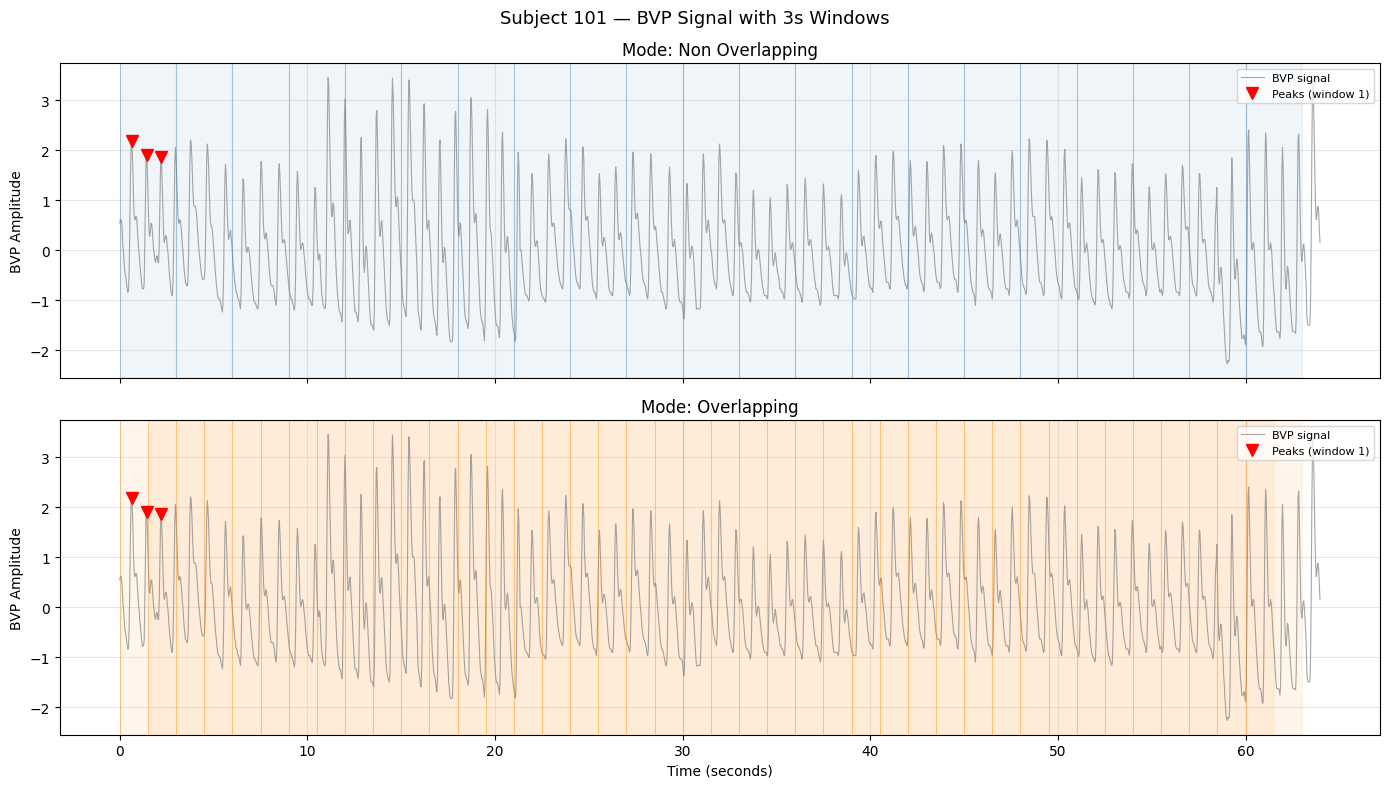

Plot saved: subject_101_windows_3s.png


In [ ]:
if __name__ == "__main__":
    
    # ============Config===============
    FPS = 30                         # Sampling rate (frames per second)
    WINDOW_SIZES_SEC = [3, 4, 5]    # Window sizes to test in seconds
    OVERLAP_RATIO = 0.5              # 50% overlap for overlapping windows
    GT_DIR = "GT_ref/"               # Directory with .npy files
    
    # Peak detection parameters (tuned for BVP signal)
    PEAK_PROMINENCE = 0.3
    PEAK_DISTANCE_SEC = 0.3    

    # 1. Load files grouped by subject
    # GT_DIR = "GT_ref/" 
    # ==============Loading files================
    subject_chunks = load_gt_npy_files(GT_DIR)
    
    # 2. Concatenate chunks per subject
    subject_signals = concatenate_subject_signal(subject_chunks)
    
    # 3. Run full analysis
    results = run_full_analysis(subject_signals, window_sizes_sec=WINDOW_SIZES_SEC)
    
    # 4. Print summary
    print_summary_table(results)
    
    # 5. Plot one subject as example
    first_subject = sorted(subject_signals.keys())[0]
    plot_subject_signal_with_windows(subject_signals[first_subject],
                                      subject_id=first_subject,
                                      window_size_sec=3)

In [9]:
GT_DIR = "GT_ref/" 
GT_DIR = "/home/muhammadu/pre_proc_datasets/PURE_intra/PURE_SizeW128_SizeH128_ClipLength160_DataTypeStandardized_DataAugNone_LabelTypeStandardized_Crop_faceTrue_Large_boxTrue_Large_size1.5_Dyamic_DetFalse_det_len30_Median_face_boxFalse"

print(f"GT_DIR set to: {GT_DIR}")
for filter in ["*_label*.npy"]:
    files = glob.glob(os.path.join(GT_DIR, filter))
    print(f"Found {len(files)} files matching '{filter}' in '{GT_DIR}'")

GT_DIR set to: /home/muhammadu/pre_proc_datasets/PURE_intra/PURE_SizeW128_SizeH128_ClipLength160_DataTypeStandardized_DataAugNone_LabelTypeStandardized_Crop_faceTrue_Large_boxTrue_Large_size1.5_Dyamic_DetFalse_det_len30_Median_face_boxFalse
Found 750 files matching '*_label*.npy' in '/home/muhammadu/pre_proc_datasets/PURE_intra/PURE_SizeW128_SizeH128_ClipLength160_DataTypeStandardized_DataAugNone_LabelTypeStandardized_Crop_faceTrue_Large_boxTrue_Large_size1.5_Dyamic_DetFalse_det_len30_Median_face_boxFalse'


In [2]:
"""
HR Estimation from BVP/PPG Signals using Sliding Windows
=========================================================
Pipeline:
  1. Load all .npy chunks per subject
  2. Concatenate chunks per subject → full signal
  3. Apply sliding window (overlapping & non-overlapping)
  4. Detect peaks per window → compute HR
  5. Mean HR per subject
"""

import os
import glob
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from collections import defaultdict


# =============================================================================
# CONFIG
# =============================================================================
FPS = 30                         # Sampling rate (frames per second)
WINDOW_SIZES_SEC = [3, 4, 5]    # Window sizes to test in seconds
OVERLAP_RATIO = 0.5              # 50% overlap for overlapping windows
GT_DIR = "GT_ref/"               # Directory with .npy files

# Peak detection parameters (tuned for BVP signal)
PEAK_PROMINENCE = 0.3
PEAK_DISTANCE_SEC = 0.3          # Min distance between peaks in seconds


# =============================================================================
# STEP 1: LOAD & GROUP BY SUBJECT
# =============================================================================
def load_gt_npy_files(gt_dir):
    """
    Load all .npy files and group by subject ID.
    
    Assumes filename format: {subject_id}_label{n}.npy
    e.g. 101_label0.npy, 101_label1.npy, ...
    
    Returns:
        dict: {subject_id: [array_chunk0, array_chunk1, ...]}
    """
    gt_files = sorted(glob.glob(os.path.join(gt_dir, '*_label*.npy')))
    
    if not gt_files:
        print(f"No label files found in {gt_dir}")
        return {}

    subject_chunks = defaultdict(list)
    
    for gt_file in gt_files:
        filename = os.path.basename(gt_file).split('.')[0]  # e.g. '101_label4'
        subject_id = filename.split('_')[0]                 # e.g. '101'
        chunk = np.load(gt_file)
        subject_chunks[subject_id].append(chunk)
    
    print(f"Loaded {len(gt_files)} files across {len(subject_chunks)} subjects")
    for subj, chunks in subject_chunks.items():
        print(f"  Subject {subj}: {len(chunks)} chunks × {chunks[0].shape[0]} samples "
              f"= {len(chunks) * chunks[0].shape[0]} total samples "
              f"≈ {len(chunks) * chunks[0].shape[0] / FPS:.1f}s")
    
    return dict(subject_chunks)


# =============================================================================
# STEP 2: CONCATENATE CHUNKS PER SUBJECT
# =============================================================================
def concatenate_subject_signal(subject_chunks):
    """
    Concatenate all chunks for each subject into one continuous signal.
    
    Returns:
        dict: {subject_id: np.array of shape (total_samples,)}
    """
    subject_signals = {}
    for subject_id, chunks in subject_chunks.items():
        signal = np.concatenate(chunks)
        subject_signals[subject_id] = signal
    return subject_signals


# =============================================================================
# STEP 3A: NON-OVERLAPPING SLIDING WINDOW
# =============================================================================
def sliding_window_non_overlapping(signal, window_size_sec, fps=FPS):
    """
    Split signal into non-overlapping windows of fixed size.
    Step = window_size (no overlap).
    
    Args:
        signal: 1D numpy array (full subject signal)
        window_size_sec: window size in seconds
        fps: sampling rate
    
    Returns:
        list of np.arrays, each of length window_size_samples
    """
    window_size = int(window_size_sec * fps)  # samples
    n_samples = len(signal)
    windows = []
    
    start = 0
    while start + window_size <= n_samples:
        window = signal[start : start + window_size]
        windows.append(window)
        start += window_size  # step = full window (no overlap)
    
    print(f"  [Non-overlapping] window={window_size_sec}s ({window_size} samples): "
          f"{len(windows)} complete windows "
          f"(discarded last {n_samples - start} samples)")
    
    return windows


# =============================================================================
# STEP 3B: OVERLAPPING SLIDING WINDOW
# =============================================================================
def sliding_window_overlapping(signal, window_size_sec, overlap_ratio=OVERLAP_RATIO, fps=FPS):
    """
    Split signal into overlapping windows.
    Step = window_size * (1 - overlap_ratio).
    
    Args:
        signal: 1D numpy array (full subject signal)
        window_size_sec: window size in seconds
        overlap_ratio: fraction of overlap (0.5 = 50%)
        fps: sampling rate
    
    Returns:
        list of np.arrays, each of length window_size_samples
    """
    window_size = int(window_size_sec * fps)               # samples
    step_size   = int(window_size * (1 - overlap_ratio))   # e.g. 50% overlap → step = half window
    n_samples   = len(signal)
    windows     = []
    
    start = 0
    while start + window_size <= n_samples:
        window = signal[start : start + window_size]
        windows.append(window)
        start += step_size
    
    print(f"  [Overlapping {int(overlap_ratio*100)}%] window={window_size_sec}s ({window_size} samples), "
          f"step={step_size} samples: {len(windows)} windows")
    
    return windows


# =============================================================================
# STEP 4: PEAK DETECTION → HR PER WINDOW
# =============================================================================
def detect_hr_from_window(window, fps=FPS,
                           prominence=PEAK_PROMINENCE,
                           min_distance_sec=PEAK_DISTANCE_SEC):
    """
    Detect peaks in a BVP window and compute HR in bpm.
    
    Args:
        window: 1D numpy array (single window of BVP signal)
        fps: sampling rate
        prominence: minimum peak prominence
        min_distance_sec: minimum distance between peaks in seconds
    
    Returns:
        float or None: HR in bpm, or None if insufficient peaks
    """
    min_distance_samples = int(fps * min_distance_sec)
    
    peaks, _ = find_peaks(window,
                           prominence=prominence,
                           distance=min_distance_samples)
    
    if len(peaks) < 2:
        return None  # Not enough peaks to compute HR
    
    # Inter-peak intervals → HR
    peak_intervals_sec = np.diff(peaks) / fps  # seconds between peaks
    hr_per_interval    = 60.0 / peak_intervals_sec  # bpm
    
    return hr_per_interval.mean()


# =============================================================================
# STEP 5: FULL HR ESTIMATION PIPELINE
# =============================================================================
def estimate_hr(signal, window_size_sec, mode='non_overlapping',
                overlap_ratio=OVERLAP_RATIO, fps=FPS):
    """
    Full pipeline: signal → windows → HR per window → mean HR.
    
    Args:
        signal: 1D numpy array (full subject signal)
        window_size_sec: window size in seconds
        mode: 'non_overlapping' or 'overlapping'
        overlap_ratio: only used if mode='overlapping'
        fps: sampling rate
    
    Returns:
        dict with:
            hr_per_window: list of HR values (bpm) per window
            mean_hr: mean HR across all valid windows
            std_hr: std of HR across all valid windows
            n_windows_total: total windows created
            n_windows_valid: windows with enough peaks
    """
    # Get windows
    if mode == 'non_overlapping':
        windows = sliding_window_non_overlapping(signal, window_size_sec, fps)
    elif mode == 'overlapping':
        windows = sliding_window_overlapping(signal, window_size_sec, overlap_ratio, fps)
    else:
        raise ValueError(f"mode must be 'non_overlapping' or 'overlapping', got '{mode}'")
    
    # HR per window
    hr_per_window = []
    for w in windows:
        hr = detect_hr_from_window(w, fps)
        if hr is not None:
            hr_per_window.append(hr)
    
    n_valid = len(hr_per_window)
    
    if n_valid == 0:
        print(f"  ⚠️  No valid windows found for window_size={window_size_sec}s")
        return {
            "hr_per_window": [],
            "mean_hr": None,
            "std_hr": None,
            "n_windows_total": len(windows),
            "n_windows_valid": 0
        }
    
    hr_array = np.array(hr_per_window)
    
    return {
        "hr_per_window": hr_per_window,
        "mean_hr": float(np.mean(hr_array)),
        "std_hr":  float(np.std(hr_array)),
        "n_windows_total": len(windows),
        "n_windows_valid": n_valid
    }


# =============================================================================
# STEP 6: RUN ON ALL SUBJECTS × ALL WINDOW SIZES
# =============================================================================
def run_full_analysis(subject_signals, window_sizes_sec=WINDOW_SIZES_SEC):
    """
    Run HR estimation for all subjects, all window sizes, both modes.
    
    Returns:
        dict: results[subject_id][window_size][mode] = estimate_hr output
    """
    results = {}
    
    for subject_id, signal in subject_signals.items():
        print(f"\n{'='*60}")
        print(f"Subject: {subject_id} | Signal length: {len(signal)} samples "
              f"≈ {len(signal)/FPS:.1f}s")
        print(f"{'='*60}")
        
        results[subject_id] = {}
        
        for ws in window_sizes_sec:
            results[subject_id][ws] = {}
            print(f"\n  Window size: {ws}s")
            
            for mode in ['non_overlapping', 'overlapping']:
                res = estimate_hr(signal, ws, mode=mode)
                results[subject_id][ws][mode] = res
                
                if res['mean_hr'] is not None:
                    print(f"    [{mode:>17}] "
                          f"Mean HR = {res['mean_hr']:5.1f} bpm | "
                          f"Std = {res['std_hr']:4.1f} | "
                          f"Valid windows = {res['n_windows_valid']}/{res['n_windows_total']}")
    
    return results


# =============================================================================
# STEP 7: SUMMARY TABLE
# =============================================================================
def print_summary_table(results):
    """Print a clean summary table of all results."""
    print(f"\n{'='*80}")
    print("SUMMARY TABLE")
    print(f"{'='*80}")
    print(f"{'Subject':<10} {'Window':>8} {'Mode':<20} {'Mean HR':>10} {'Std':>8} {'Valid/Total':>12}")
    print(f"{'-'*80}")
    
    for subject_id in sorted(results.keys()):
        for ws in sorted(results[subject_id].keys()):
            for mode in ['non_overlapping', 'overlapping']:
                res = results[subject_id][ws][mode]
                mean = f"{res['mean_hr']:.1f}" if res['mean_hr'] else "N/A"
                std  = f"{res['std_hr']:.1f}"  if res['std_hr']  else "N/A"
                valid = f"{res['n_windows_valid']}/{res['n_windows_total']}"
                print(f"{subject_id:<10} {str(ws)+'s':>8} {mode:<20} {mean:>10} {std:>8} {valid:>12}")
        print(f"{'-'*80}")


# =============================================================================
# STEP 8: VISUALIZATION
# =============================================================================
def plot_subject_signal_with_windows(signal, subject_id, window_size_sec=3, fps=FPS):
    """
    Plot the full subject signal with window boundaries overlaid.
    """
    window_size = int(window_size_sec * fps)
    time_axis   = np.arange(len(signal)) / fps
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f"Subject {subject_id} — BVP Signal with {window_size_sec}s Windows", fontsize=13)
    
    for ax, mode, color in zip(axes,
                                ['non_overlapping', 'overlapping'],
                                ['steelblue', 'darkorange']):
        ax.plot(time_axis, signal, color='gray', linewidth=0.8, alpha=0.7, label='BVP signal')
        
        # Get windows
        if mode == 'non_overlapping':
            windows_list = sliding_window_non_overlapping(signal, window_size_sec, fps)
            step = window_size
        else:
            step = int(window_size * (1 - OVERLAP_RATIO))
            windows_list = sliding_window_overlapping(signal, window_size_sec, fps=fps)
        
        # Draw window boundaries
        for i in range(len(windows_list)):
            start_t = (i * step) / fps
            end_t   = start_t + window_size_sec
            ax.axvspan(start_t, end_t, alpha=0.08, color=color)
            ax.axvline(start_t, color=color, linewidth=0.5, alpha=0.5)
        
        # Detect and plot peaks for first window as example
        w0 = windows_list[0]
        peaks, _ = find_peaks(w0, prominence=PEAK_PROMINENCE,
                              distance=int(fps * PEAK_DISTANCE_SEC))
        peak_times = peaks / fps
        ax.plot(peak_times, w0[peaks], 'rv', markersize=8, label='Peaks (window 1)')
        
        ax.set_ylabel("BVP Amplitude")
        ax.set_title(f"Mode: {mode.replace('_', ' ').title()}")
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel("Time (seconds)")
    plt.tight_layout()
    plt.savefig(f"subject_{subject_id}_windows_{window_size_sec}s.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved: subject_{subject_id}_windows_{window_size_sec}s.png")


# =============================================================================
# MAIN
# =============================================================================
# if __name__ == "__main__":
    
#     # 1. Load files grouped by subject
#     subject_chunks = load_gt_npy_files(GT_DIR)
    
#     # 2. Concatenate chunks per subject
#     subject_signals = concatenate_subject_signal(subject_chunks)
    
#     # 3. Run full analysis
#     results = run_full_analysis(subject_signals, window_sizes_sec=WINDOW_SIZES_SEC)
    
#     # 4. Print summary
#     print_summary_table(results)
    
#     # 5. Plot one subject as example
#     first_subject = sorted(subject_signals.keys())[0]
#     plot_subject_signal_with_windows(subject_signals[first_subject],
#                                       subject_id=first_subject,
#                                       window_size_sec=3)

Loaded 750 files across 59 subjects
  Subject 1001: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 1002: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 1003: 14 chunks × 160 samples = 2240 total samples ≈ 74.7s
  Subject 1004: 14 chunks × 160 samples = 2240 total samples ≈ 74.7s
  Subject 1005: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 1006: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 101: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 102: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 103: 15 chunks × 160 samples = 2400 total samples ≈ 80.0s
  Subject 104: 15 chunks × 160 samples = 2400 total samples ≈ 80.0s
  Subject 105: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 106: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 201: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 202: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subj

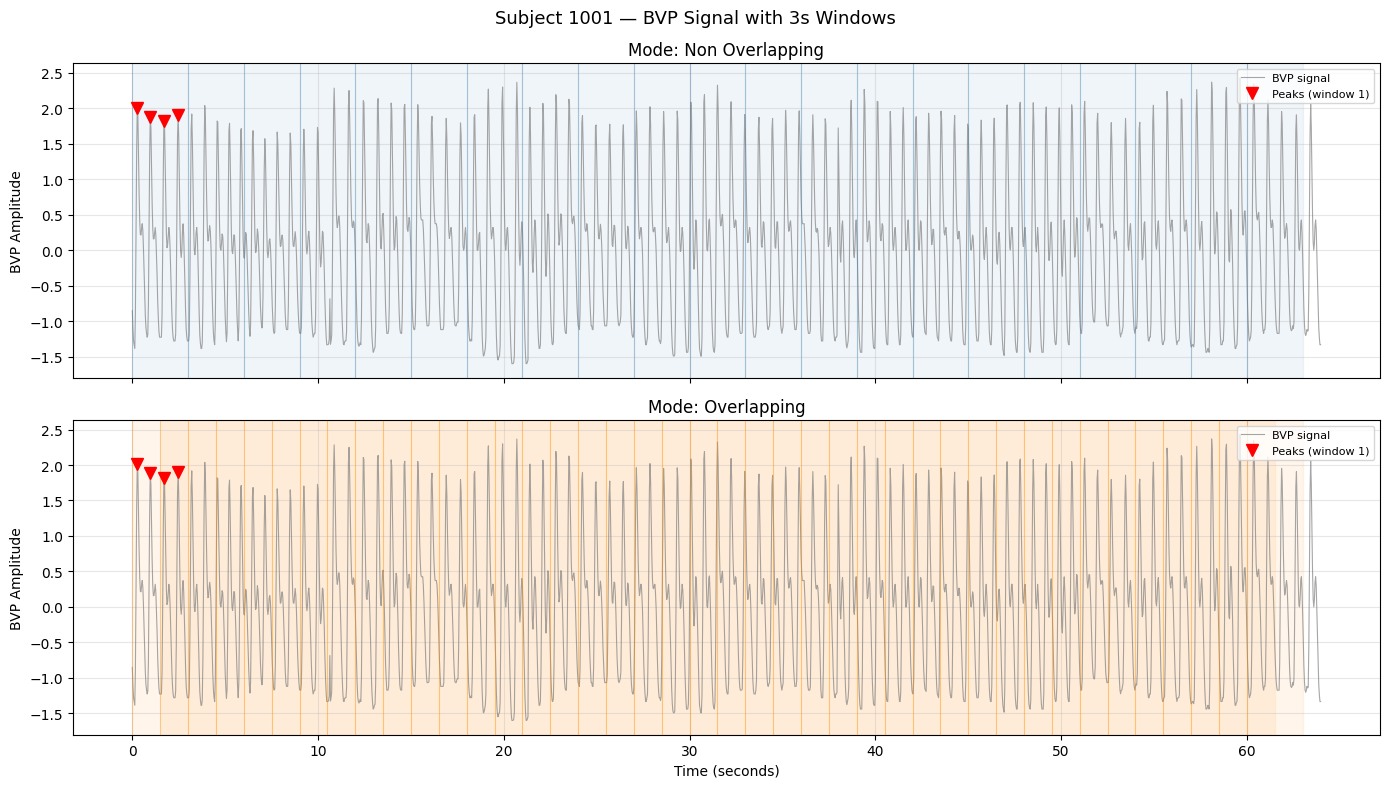

Plot saved: subject_1001_windows_3s.png


In [3]:
if __name__ == "__main__":
    
    # ============Config===============
    FPS = 30                         # Sampling rate (frames per second)
    WINDOW_SIZES_SEC = [3, 4, 5]    # Window sizes to test in seconds
    OVERLAP_RATIO = 0.5              # 50% overlap for overlapping windows
    # GT_DIR = "GT_ref/"               # Directory with .npy files
    GT_DIR = "/home/muhammadu/pre_proc_datasets/PURE_intra/PURE_SizeW128_SizeH128_ClipLength160_DataTypeStandardized_DataAugNone_LabelTypeStandardized_Crop_faceTrue_Large_boxTrue_Large_size1.5_Dyamic_DetFalse_det_len30_Median_face_boxFalse"
    
    # Peak detection parameters (tuned for BVP signal)
    PEAK_PROMINENCE = 0.3
    PEAK_DISTANCE_SEC = 0.3    

    # 1. Load files grouped by subject
    # GT_DIR = "GT_ref/" 
    # ==============Loading files================
    subject_chunks = load_gt_npy_files(GT_DIR)
    
    # 2. Concatenate chunks per subject
    subject_signals = concatenate_subject_signal(subject_chunks)
    
    # 3. Run full analysis
    results = run_full_analysis(subject_signals, window_sizes_sec=WINDOW_SIZES_SEC)
    
    # 4. Print summary
    print_summary_table(results)
    
    # 5. Plot one subject as example
    first_subject = sorted(subject_signals.keys())[0]
    plot_subject_signal_with_windows(subject_signals[first_subject],
                                      subject_id=first_subject,
                                      window_size_sec=3)

✅ Results exported to: hr_results.csv
   Shape: (354, 8)
   Subjects: 59


/tmp/ipykernel_133701/1395549832.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=[f"{ws}s" for ws in window_sizes],


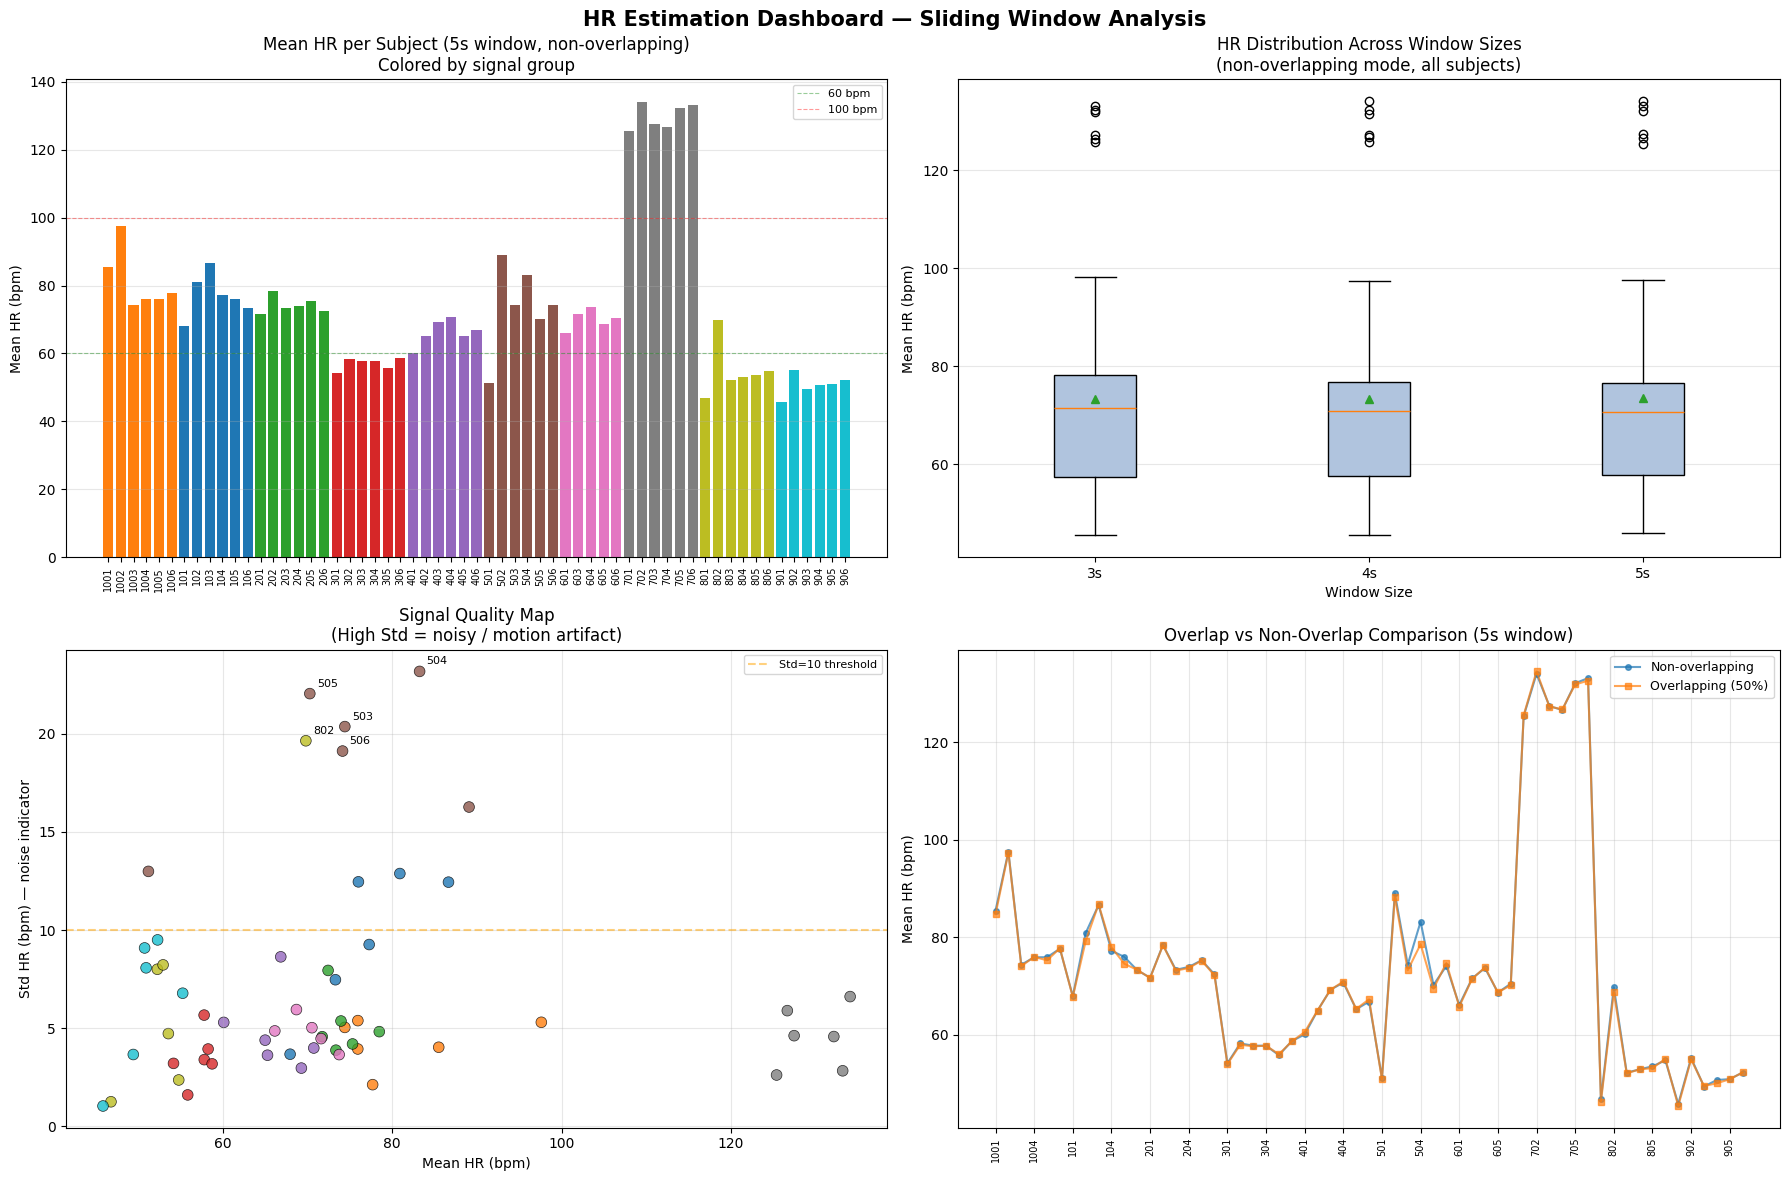

✅ Dashboard saved: hr_dashboard.png

⚠️  NOISY SUBJECTS (Std > 10 bpm, 5s non_overlapping)
  Subject    504: Mean=83.2 bpm, Std=23.2 bpm
  Subject    505: Mean=70.3 bpm, Std=22.0 bpm
  Subject    503: Mean=74.4 bpm, Std=20.4 bpm
  Subject    802: Mean=69.8 bpm, Std=19.6 bpm
  Subject    506: Mean=74.1 bpm, Std=19.1 bpm
  Subject    502: Mean=89.1 bpm, Std=16.3 bpm
  Subject    501: Mean=51.2 bpm, Std=13.0 bpm
  Subject    102: Mean=80.9 bpm, Std=12.9 bpm
  Subject    105: Mean=76.0 bpm, Std=12.5 bpm
  Subject    103: Mean=86.6 bpm, Std=12.4 bpm


In [4]:
"""
Part B: Export results to CSV + Visualization Dashboard
==========================================================
Run this AFTER you have the `results` dict from run_full_analysis().

Usage:
    subject_signals = concatenate_subject_signal(subject_chunks)
    results = run_full_analysis(subject_signals, window_sizes_sec=WINDOW_SIZES_SEC)
    print_summary_table(results)

    # NEW PART:
    df = export_results_to_csv(results, "hr_results.csv")
    plot_dashboard(df)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# A. EXPORT RESULTS TO CSV
# =============================================================================
def export_results_to_csv(results, output_path="hr_results.csv"):
    """
    Flatten the nested `results` dict into a tidy DataFrame and save as CSV.

    Columns:
        subject, window_size_sec, mode, mean_hr, std_hr,
        n_windows_valid, n_windows_total, signal_group
    """
    rows = []

    for subject_id, window_dict in results.items():
        for window_size, mode_dict in window_dict.items():
            for mode, res in mode_dict.items():
                rows.append({
                    "subject": subject_id,
                    "window_size_sec": window_size,
                    "mode": mode,
                    "mean_hr": res["mean_hr"],
                    "std_hr": res["std_hr"],
                    "n_windows_valid": res["n_windows_valid"],
                    "n_windows_total": res["n_windows_total"],
                    # Group subjects by their series prefix (101->1, 1001->1, 701->7 etc.)
                    "signal_group": str(subject_id)[0] if len(str(subject_id)) == 3 
                                    else str(subject_id)[:2]
                })

    df = pd.DataFrame(rows)
    df.to_csv(output_path, index=False)
    print(f"✅ Results exported to: {output_path}")
    print(f"   Shape: {df.shape}")
    print(f"   Subjects: {df['subject'].nunique()}")
    
    return df


# =============================================================================
# B. VISUALIZATION DASHBOARD
# =============================================================================
def plot_dashboard(df, save_prefix="hr_dashboard"):
    """
    Create a multi-panel dashboard:
        1. Bar chart - Mean HR per subject (colored by group)
        2. Box plot - HR distribution per window size
        3. Scatter - Std vs Mean HR (identify noisy subjects)
        4. Line plot - Mean HR comparison: overlap vs non-overlap
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle("HR Estimation Dashboard — Sliding Window Analysis", fontsize=15, fontweight='bold')

    # Use 5s non-overlapping as the "reference" estimate for plots 1 & 3
    df_ref = df[(df["window_size_sec"] == 5) & (df["mode"] == "non_overlapping")].copy()
    df_ref = df_ref.sort_values("subject")

    # -------------------------------------------------------------------
    # Panel 1: Bar chart - Mean HR per subject (colored by group)
    # -------------------------------------------------------------------
    ax1 = axes[0, 0]
    groups = df_ref["signal_group"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))
    color_map = dict(zip(sorted(groups), colors))
    bar_colors = df_ref["signal_group"].map(color_map)

    ax1.bar(range(len(df_ref)), df_ref["mean_hr"], color=bar_colors)
    ax1.set_xticks(range(len(df_ref)))
    ax1.set_xticklabels(df_ref["subject"], rotation=90, fontsize=7)
    ax1.set_ylabel("Mean HR (bpm)")
    ax1.set_title("Mean HR per Subject (5s window, non-overlapping)\nColored by signal group")
    ax1.axhline(60, color='green', linestyle='--', alpha=0.4, linewidth=0.8, label='60 bpm')
    ax1.axhline(100, color='red', linestyle='--', alpha=0.4, linewidth=0.8, label='100 bpm')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3, axis='y')

    # -------------------------------------------------------------------
    # Panel 2: Box plot - HR distribution per window size
    # -------------------------------------------------------------------
    ax2 = axes[0, 1]
    window_sizes = sorted(df["window_size_sec"].unique())
    box_data = [df[(df["window_size_sec"] == ws) & 
                    (df["mode"] == "non_overlapping")]["mean_hr"].dropna()
                for ws in window_sizes]

    bp = ax2.boxplot(box_data, labels=[f"{ws}s" for ws in window_sizes],
                      patch_artist=True, showmeans=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue')

    ax2.set_ylabel("Mean HR (bpm)")
    ax2.set_xlabel("Window Size")
    ax2.set_title("HR Distribution Across Window Sizes\n(non-overlapping mode, all subjects)")
    ax2.grid(True, alpha=0.3, axis='y')

    # -------------------------------------------------------------------
    # Panel 3: Scatter - Std vs Mean HR (identify noisy subjects)
    # -------------------------------------------------------------------
    ax3 = axes[1, 0]
    scatter = ax3.scatter(df_ref["mean_hr"], df_ref["std_hr"],
                          c=bar_colors, s=60, edgecolors='black', linewidth=0.5, alpha=0.8)

    # Annotate top 5 noisiest subjects
    noisy = df_ref.nlargest(5, "std_hr")
    for _, row in noisy.iterrows():
        ax3.annotate(str(row["subject"]),
                     (row["mean_hr"], row["std_hr"]),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')

    ax3.set_xlabel("Mean HR (bpm)")
    ax3.set_ylabel("Std HR (bpm) — noise indicator")
    ax3.set_title("Signal Quality Map\n(High Std = noisy / motion artifact)")
    ax3.axhline(10, color='orange', linestyle='--', alpha=0.5, label='Std=10 threshold')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    # -------------------------------------------------------------------
    # Panel 4: Line plot - Overlap vs Non-overlap comparison
    # -------------------------------------------------------------------
    ax4 = axes[1, 1]
    df_5s = df[df["window_size_sec"] == 5].copy()
    pivot = df_5s.pivot(index="subject", columns="mode", values="mean_hr").sort_index()

    x = np.arange(len(pivot))
    ax4.plot(x, pivot["non_overlapping"], 'o-', label='Non-overlapping', alpha=0.7, markersize=4)
    ax4.plot(x, pivot["overlapping"], 's-', label='Overlapping (50%)', alpha=0.7, markersize=4)

    ax4.set_xticks(x[::3])  # show every 3rd label to avoid crowding
    ax4.set_xticklabels(pivot.index[::3], rotation=90, fontsize=7)
    ax4.set_ylabel("Mean HR (bpm)")
    ax4.set_title("Overlap vs Non-Overlap Comparison (5s window)")
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{save_prefix}.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Dashboard saved: {save_prefix}.png")

    return fig


# =============================================================================
# BONUS: Quick noisy-subject report
# =============================================================================
def flag_noisy_subjects(df, std_threshold=10, window_size=5, mode="non_overlapping"):
    """
    Print a quick report of subjects whose HR estimate has high variability,
    which may indicate motion artifacts or poor signal quality.
    """
    subset = df[(df["window_size_sec"] == window_size) & (df["mode"] == mode)]
    noisy = subset[subset["std_hr"] > std_threshold].sort_values("std_hr", ascending=False)

    print(f"\n{'='*60}")
    print(f"⚠️  NOISY SUBJECTS (Std > {std_threshold} bpm, {window_size}s {mode})")
    print(f"{'='*60}")
    if noisy.empty:
        print("None found — all signals look clean!")
    else:
        for _, row in noisy.iterrows():
            print(f"  Subject {row['subject']:>6}: Mean={row['mean_hr']:.1f} bpm, "
                  f"Std={row['std_hr']:.1f} bpm")

    return noisy


# =============================================================================
# MAIN (example usage — append after your existing pipeline)
# =============================================================================
if __name__ == "__main__":
    # These come from your existing code:
    # subject_chunks  = load_gt_npy_files(GT_DIR)
    # subject_signals = concatenate_subject_signal(subject_chunks)
    # results         = run_full_analysis(subject_signals, window_sizes_sec=WINDOW_SIZES_SEC)
    # print_summary_table(results)

    # NEW: export + visualize
    df = export_results_to_csv(results, "hr_results.csv")
    plot_dashboard(df)
    flag_noisy_subjects(df, std_threshold=10)

Loaded 750 files across 59 subjects
  Subject 1001: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 1002: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 1003: 14 chunks × 160 samples = 2240 total samples ≈ 74.7s
  Subject 1004: 14 chunks × 160 samples = 2240 total samples ≈ 74.7s
  Subject 1005: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 1006: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 101: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 102: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 103: 15 chunks × 160 samples = 2400 total samples ≈ 80.0s
  Subject 104: 15 chunks × 160 samples = 2400 total samples ≈ 80.0s
  Subject 105: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 106: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 201: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subject 202: 12 chunks × 160 samples = 1920 total samples ≈ 64.0s
  Subj

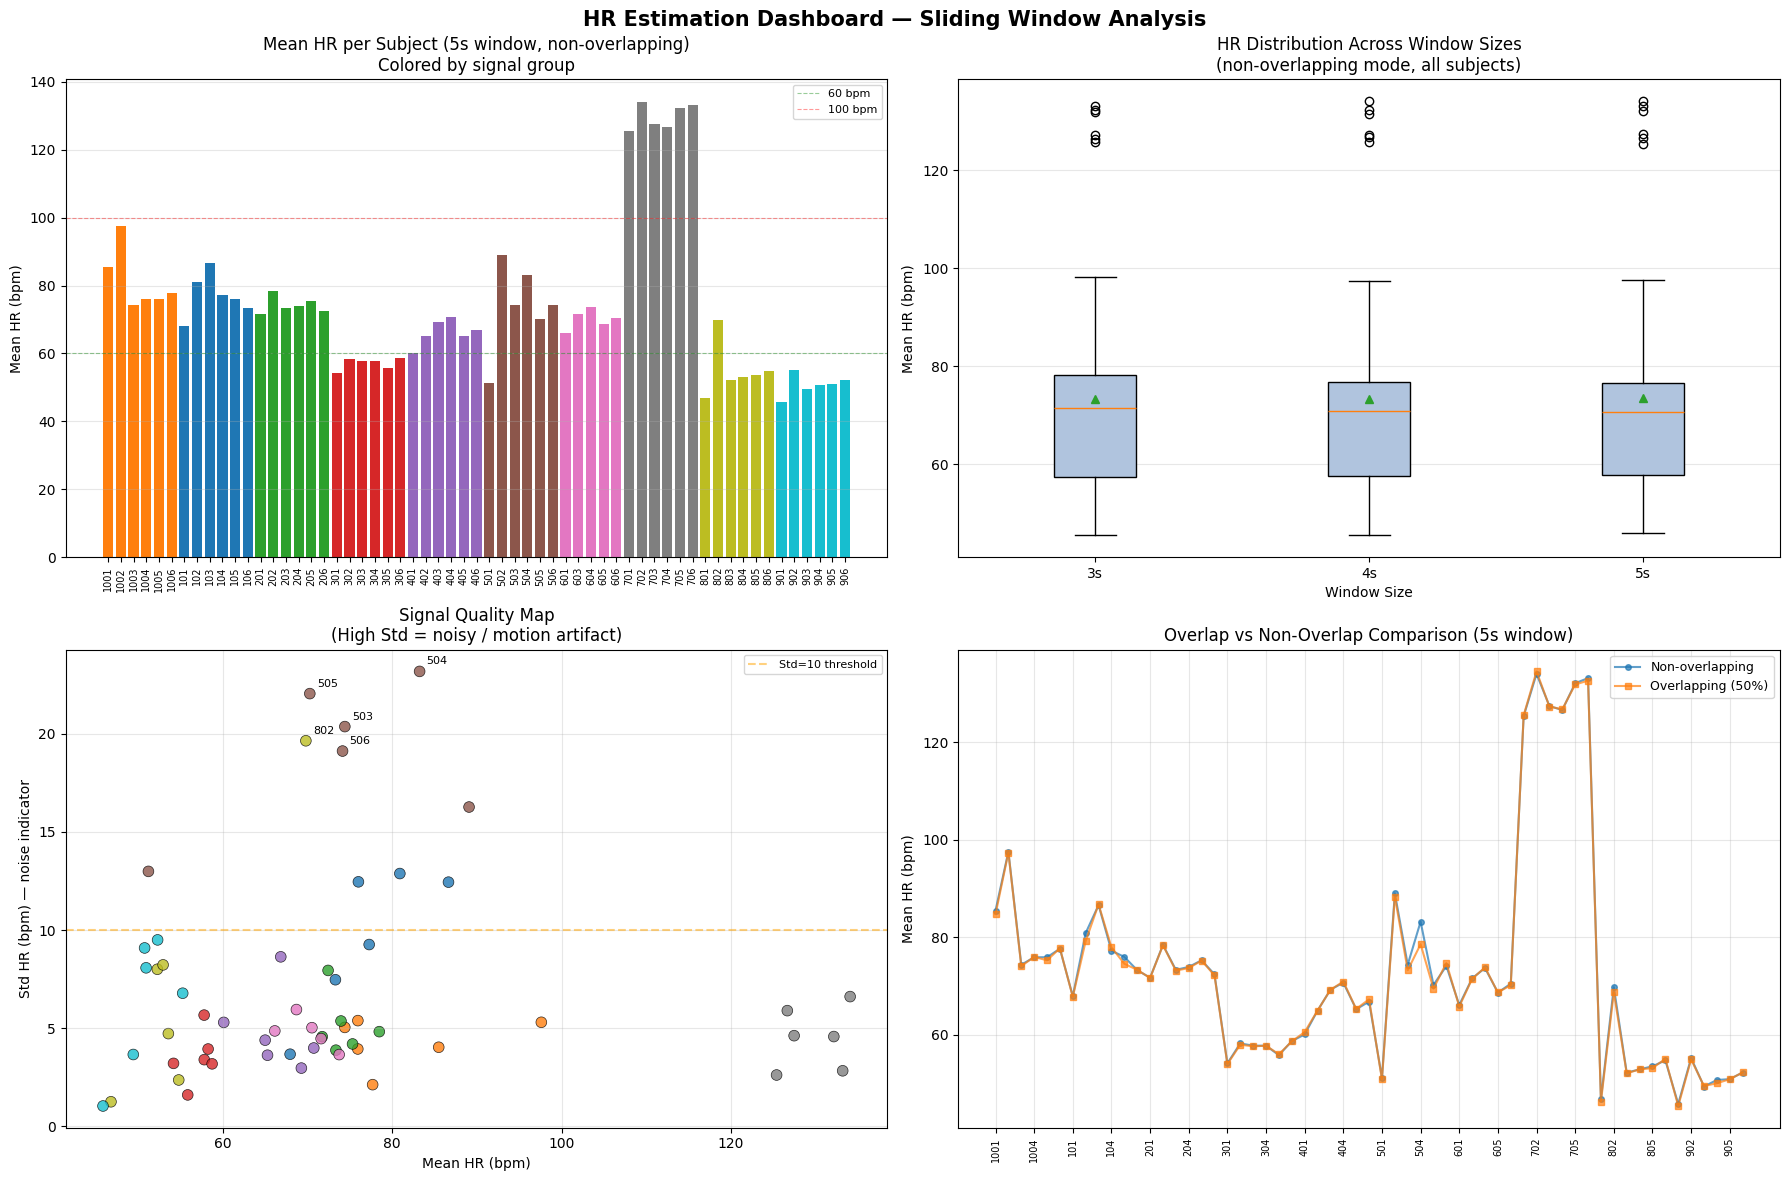

✅ Dashboard saved: hr_dashboard.png

⚠️  NOISY SUBJECTS (Std > 10 bpm, 5s non_overlapping)
  Subject    504: Mean=83.2 bpm, Std=23.2 bpm
  Subject    505: Mean=70.3 bpm, Std=22.0 bpm
  Subject    503: Mean=74.4 bpm, Std=20.4 bpm
  Subject    802: Mean=69.8 bpm, Std=19.6 bpm
  Subject    506: Mean=74.1 bpm, Std=19.1 bpm
  Subject    502: Mean=89.1 bpm, Std=16.3 bpm
  Subject    501: Mean=51.2 bpm, Std=13.0 bpm
  Subject    102: Mean=80.9 bpm, Std=12.9 bpm
  Subject    105: Mean=76.0 bpm, Std=12.5 bpm
  Subject    103: Mean=86.6 bpm, Std=12.4 bpm


,subject,window_size_sec,mode,mean_hr,std_hr,n_windows_valid,n_windows_total,signal_group
202,504,5,non_overlapping,83.224794,23.178198,14,14,5
208,505,5,non_overlapping,70.257147,22.046145,12,12,5
196,503,5,non_overlapping,74.394424,20.366502,14,14,5
292,802,5,non_overlapping,69.792311,19.644737,12,12,8
214,506,5,non_overlapping,74.124783,19.120684,12,12,5
190,502,5,non_overlapping,89.063652,16.269498,12,12,5
184,501,5,non_overlapping,51.199545,12.991879,12,12,5
46,102,5,non_overlapping,80.890959,12.881523,12,12,1
64,105,5,non_overlapping,75.996981,12.459951,12,12,1
52,103,5,non_overlapping,86.634191,12.443073,16,16,1


In [ ]:
from hr_estimation import (
    load_gt_npy_files,
    concatenate_subject_signal,
    run_full_analysis,
    print_summary_table,
)
from hr_analysis_export import (
    export_results_to_csv,
    plot_dashboard,
    flag_noisy_subjects,
)

GT_DIR = "/home/muhammadu/pre_proc_datasets/PURE_intra/PURE_SizeW128_SizeH128_ClipLength160_DataTypeStandardized_DataAugNone_LabelTypeStandardized_Crop_faceTrue_Large_boxTrue_Large_size1.5_Dyamic_DetFalse_det_len30_Median_face_boxFalse"

# 1. Load and process
subject_chunks  = load_gt_npy_files(GT_DIR)
subject_signals = concatenate_subject_signal(subject_chunks)

# 2. Run sliding-window HR estimation
results = run_full_analysis(subject_signals, window_sizes_sec=[3, 4, 5])
print_summary_table(results)

# 3. Export + visualize
df = export_results_to_csv(results, "hr_results.csv")
plot_dashboard(df)
flag_noisy_subjects(df, std_threshold=10)